# Init Method Comparison From 3 Result CSVs

This notebook loads the 3 benchmark CSV files in `src/results`, aggregates results, and identifies which initialization method performs best.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)

In [2]:
# Resolve results directory
ROOT = Path.cwd()
results_dir = ROOT / 'src' / 'results'
if not results_dir.exists():
    results_dir = ROOT / 'results'

assert results_dir.exists(), f'Results directory not found: {results_dir}'

csv_files = sorted(results_dir.glob('benchmark_*.csv'), key=lambda p: p.stat().st_mtime, reverse=True)
assert len(csv_files) >= 3, f'Expected at least 3 benchmark CSV files, found {len(csv_files)}'

selected_csvs = sorted(csv_files[:3])
print('Using CSV files:')
for path in selected_csvs:
    print('-', path.name)

Using CSV files:
- benchmark_C201_20260407_174323.csv
- benchmark_R201_20260407_180142.csv
- benchmark_RC201_20260407_181404.csv


In [3]:
def infer_group(instance_name: str) -> str:
    if instance_name.startswith('RC'):
        return 'RC'
    if instance_name.startswith('R'):
        return 'R'
    if instance_name.startswith('C'):
        return 'C'
    return 'OTHER'

frames = []
for csv_path in selected_csvs:
    df = pd.read_csv(csv_path)
    df['source_csv'] = csv_path.name

    if 'benchmark_stage' in df.columns:
        df = df[df['benchmark_stage'] == 'tabu'].copy()

    if 'tabu_distance' in df.columns:
        df['best_distance'] = pd.to_numeric(df['tabu_distance'], errors='coerce')
    elif 'final_distance' in df.columns:
        df['best_distance'] = pd.to_numeric(df['final_distance'], errors='coerce')
    else:
        df['best_distance'] = pd.to_numeric(df.get('distance', np.nan), errors='coerce')

    if 'init_distance' in df.columns:
        df['init_distance_num'] = pd.to_numeric(df['init_distance'], errors='coerce')
    elif 'initial_distance' in df.columns:
        df['init_distance_num'] = pd.to_numeric(df['initial_distance'], errors='coerce')
    else:
        df['init_distance_num'] = np.nan

    if 'total_elapsed_seconds' in df.columns:
        df['runtime_sec'] = pd.to_numeric(df['total_elapsed_seconds'], errors='coerce')
    else:
        df['runtime_sec'] = pd.to_numeric(df.get('elapsed_seconds', np.nan), errors='coerce')

    if 'method' not in df.columns:
        df['method'] = df.get('init_method', 'unknown')

    if 'instance' not in df.columns:
        raise ValueError(f'Missing instance column in {csv_path.name}')

    df['group'] = df['instance'].astype(str).map(infer_group)
    df['improvement_pct'] = np.where(
        df['init_distance_num'] > 0,
        (df['init_distance_num'] - df['best_distance']) / df['init_distance_num'] * 100.0,
        np.nan
    )

    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
all_df = all_df[all_df['best_distance'].notna()].copy()

print('Rows loaded:', len(all_df))
all_df[['instance', 'group', 'method', 'init_distance_num', 'best_distance', 'runtime_sec', 'source_csv']].head(10)

Rows loaded: 15


,instance,group,method,init_distance_num,best_distance,runtime_sec,source_csv
0,C201,C,greedy,1880.468130,838.392188,13.268504,benchmark_C201_20260407_174323.csv
1,C201,C,solomon,642.222321,591.556557,89.256918,benchmark_C201_20260407_174323.csv
2,C201,C,clarke_wright,1029.662763,694.330850,36.696631,benchmark_C201_20260407_174323.csv
3,C201,C,random,2968.781061,625.379287,38.695409,benchmark_C201_20260407_174323.csv
4,C201,C,sweep,1668.876214,1049.203138,11.841332,benchmark_C201_20260407_174323.csv
5,R201,R,greedy,1984.955876,1429.195857,9.486925,benchmark_R201_20260407_180142.csv
6,R201,R,solomon,1782.035376,1415.300168,54.610296,benchmark_R201_20260407_180142.csv
7,R201,R,clarke_wright,1396.532445,1323.250669,9.628864,benchmark_R201_20260407_180142.csv
8,R201,R,random,3043.296825,1468.434264,17.562063,benchmark_R201_20260407_180142.csv
9,R201,R,sweep,1937.815912,1422.988138,10.213287,benchmark_R201_20260407_180142.csv


In [4]:
# Overall method ranking
overall = (
    all_df.groupby('method', as_index=False)
    .agg(
        runs=('best_distance', 'count'),
        avg_best_distance=('best_distance', 'mean'),
        avg_init_distance=('init_distance_num', 'mean'),
        avg_runtime_sec=('runtime_sec', 'mean'),
        avg_improvement_pct=('improvement_pct', 'mean')
    )
    .sort_values('avg_best_distance')
)

best_overall = overall.iloc[0]
print(f"Best overall method: {best_overall['method']} (avg_best_distance={best_overall['avg_best_distance']:.3f})")
overall

Best overall method: solomon (avg_best_distance=1172.863)


,method,runs,avg_best_distance,avg_init_distance,avg_runtime_sec,avg_improvement_pct
3,solomon,3,1172.862990,1558.813370,57.020596,20.448569
0,clarke_wright,3,1206.398688,1361.230009,18.537855,13.728646
2,random,3,1274.312242,3306.841418,23.434360,62.147568
1,greedy,3,1379.563581,2111.223207,10.863717,35.869130
4,sweep,3,1510.627928,2122.804739,10.864457,29.706192


In [5]:
# Grouped ranking: R, C, RC
grouped = (
    all_df.groupby(['group', 'method'], as_index=False)
    .agg(
        runs=('best_distance', 'count'),
        avg_best_distance=('best_distance', 'mean'),
        avg_init_distance=('init_distance_num', 'mean'),
        avg_runtime_sec=('runtime_sec', 'mean'),
        avg_improvement_pct=('improvement_pct', 'mean')
    )
    .sort_values(['group', 'avg_best_distance'])
)

grouped

,group,method,runs,avg_best_distance,avg_init_distance,avg_runtime_sec,avg_improvement_pct
3,C,solomon,1,591.556557,642.222321,89.256918,7.889132
2,C,random,1,625.379287,2968.781061,38.695409,78.934813
0,C,clarke_wright,1,694.330850,1029.662763,36.696631,32.567159
1,C,greedy,1,838.392188,1880.468130,13.268504,55.415773
4,C,sweep,1,1049.203138,1668.876214,11.841332,37.131159
5,R,clarke_wright,1,1323.250669,1396.532445,9.628864,5.247409
8,R,solomon,1,1415.300168,1782.035376,54.610296,20.579569
9,R,sweep,1,1422.988138,1937.815912,10.213287,26.567424
6,R,greedy,1,1429.195857,1984.955876,9.486925,27.998608
7,R,random,1,1468.434264,3043.296825,17.562063,51.748569


In [6]:
# Best method by each family
best_by_group = grouped.loc[grouped.groupby('group')['avg_best_distance'].idxmin()].sort_values('group')
best_by_group[['group', 'method', 'avg_best_distance', 'avg_runtime_sec', 'avg_improvement_pct']]

,group,method,avg_best_distance,avg_runtime_sec,avg_improvement_pct
3,C,solomon,591.556557,89.256918,7.889132
5,R,clarke_wright,1323.250669,9.628864,5.247409
13,RC,solomon,1511.732244,27.194574,32.877007


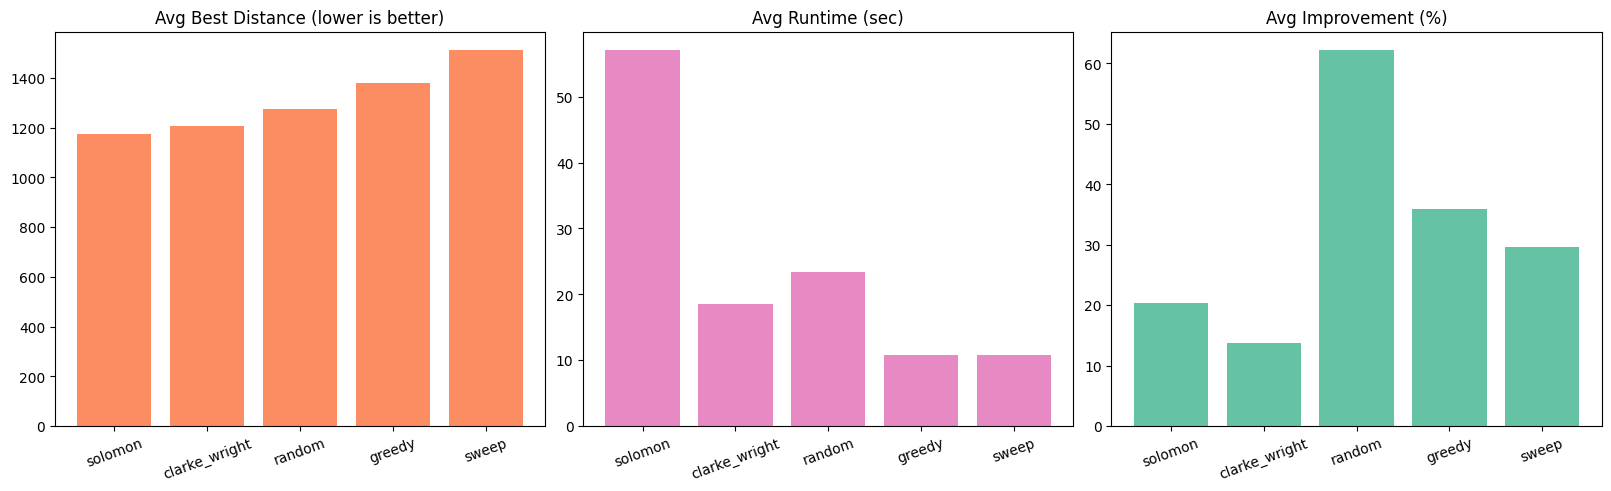

In [7]:
# Comparative plots
plot_df = overall.copy()
x = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

axes[0].bar(x, plot_df['avg_best_distance'], color='#fc8d62')
axes[0].set_title('Avg Best Distance (lower is better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df['method'], rotation=20)

axes[1].bar(x, plot_df['avg_runtime_sec'], color='#e78ac3')
axes[1].set_title('Avg Runtime (sec)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df['method'], rotation=20)

axes[2].bar(x, plot_df['avg_improvement_pct'], color='#66c2a5')
axes[2].set_title('Avg Improvement (%)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(plot_df['method'], rotation=20)

plt.show()

In [8]:
# Optional: save aggregated tables
out_dir = results_dir
overall_path = out_dir / 'three_csv_overall_method_average.csv'
grouped_path = out_dir / 'three_csv_group_method_average.csv'
best_path = out_dir / 'three_csv_best_method_by_group.csv'

overall.to_csv(overall_path, index=False)
grouped.to_csv(grouped_path, index=False)
best_by_group.to_csv(best_path, index=False)

print('Saved:')
print('-', overall_path.name)
print('-', grouped_path.name)
print('-', best_path.name)

Saved:
- three_csv_overall_method_average.csv
- three_csv_group_method_average.csv
- three_csv_best_method_by_group.csv
